In [7]:
# data/
# ├── test_images/ (... 2000 items .jpg)
# ├── train/
# │   ├── images/ (... 2000 items .jpg)
# │   └── masks/ (... 2000 items .png)
# └── unlabeled/
#     └── images/ (... 350 items .jpg)
#
# bg/ (... 15 items .jpg)
# └── <ip>.jpg

import numpy as np
import cv2

from scipy.ndimage import median_filter

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from pathlib import Path
import os
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
import random

np.random.seed(0xB00B5)

In [8]:
DATA_ROOT = Path('./data')
IMGS_DIR = DATA_ROOT / 'train' / 'images'
MASK_DIR = DATA_ROOT / 'train' / 'masks'
BG_DIR = Path('./bg')

def get_loc(fn):
    return fn.split('_')[0]

def imload(fname) -> np.ndarray:
    im = cv2.imread(f"{IMGS_DIR / fname}.jpg")
    if im is None: raise RuntimeError
    return im

def maskload(fname) -> np.ndarray:
    m = cv2.imread(f"{MASK_DIR / fname}.png", 0)
    if m is None: raise RuntimeError
    return m

def bgload(fname=None, ip=None) -> np.ndarray:
    if (fname is None) + (ip is None) != 1: raise ValueError("Either fname or ip")
    if ip is None: ip = get_loc(fname)
    im = cv2.imread(f"{BG_DIR / ip}.jpg")
    if im is None: raise RuntimeError
    return im

def load_batch(fns) -> tuple[np.ndarray, np.ndarray]:
    if not fns: return np.array([]), np.array([])
    im0, m0 = imload(fns[0]), maskload(fns[0])
    h, w = im0.shape[:2]
    b = len(fns)
    imgs = np.empty((b, h, w, 3), dtype=np.uint8)
    masks = np.empty((b, h, w), dtype=np.uint8)    
    imgs[0], masks[0] = im0, m0
    def worker(i):
        imgs[i] = imload(fns[i])
        masks[i] = maskload(fns[i])
    if b > 1:
        with ThreadPoolExecutor() as executor:
            list(executor.map(worker, range(1, b)))
    return imgs, masks

FNS = sorted(map(lambda x: x.replace('.jpg', ''), os.listdir(IMGS_DIR)))
LOCS = defaultdict(list)
for fn in FNS:
    ip = get_loc(fn)
    LOCS[ip].append(fn)
LOCS.keys()

dict_keys(['10.107.215.111', '10.107.224.111', '10.113.216.111', '10.115.12.111', '10.115.67.239', '10.51.118.111', '10.69.85.239', '10.80.139.239', '10.88.142.239', '10.88.219.239', '10.88.220.111', '10.88.31.239', '10.89.115.111', '10.91.132.111', '10.96.235.111'])

In [9]:
CMAP_CUSTOM = {'r': mcolors.LinearSegmentedColormap.from_list('r', ['#000000', '#ff0000']),
               'g': mcolors.LinearSegmentedColormap.from_list('g', ['#000000', '#00ff00']),
               'b': mcolors.LinearSegmentedColormap.from_list('b', ['#000000', '#0000ff']),
               'c': mcolors.LinearSegmentedColormap.from_list('c', ['#000000', '#00ffff']),
               'm': mcolors.LinearSegmentedColormap.from_list('m', ['#000000', '#ff00ff']),
               'y': mcolors.LinearSegmentedColormap.from_list('y', ['#000000', '#ffff00']),
               'v': mcolors.LinearSegmentedColormap.from_list('v', ['#000000', '#ffffff']),
               '.': 'gray'}

def imshow(*imgs, title: str|None = None, grid=None, subtitles: list|None=None, cmap=None, bound=False):
    if len(imgs) == 1 and isinstance(imgs[0], dict):
        subtitles = list(imgs[0].keys())
        imgs = list(imgs[0].values())
    n = len(imgs)
    if n == 0: raise ValueError('no ims')

    if isinstance(cmap, str) and set(cmap).issubset(CMAP_CUSTOM.keys()):
        cmapmap = {i: CMAP_CUSTOM.get(c) for i,c in enumerate(cmap)}
    elif isinstance(cmap, dict): cmapmap = cmap
    else: cmapmap = {i: cmap for i in range(n)}
    
    subt_iter = iter(subtitles) if subtitles else None
    nv, nh = grid if grid else (1, n)
    fig, axs = plt.subplots(nv, nh, figsize=(nh * 5, nv * 5), squeeze=False)
    axs = axs.flatten()
    for i, ax in enumerate(axs):
        ax.axis('off')
        if i < n and imgs[i] is not None:
            im = imgs[i]
            cm = cmapmap.get(i, 'gray')
            is_gray = im.ndim == 2 or (im.ndim == 3 and im.shape[-1] == 1)
            if not is_gray and not (im.ndim == 3 and im.shape[-1] == 3): raise ValueError(f"{im.shape} -- neither HxW nor HxWx1 nor HxWx3")
            if is_gray:
                if im.ndim == 3: im = im.squeeze(-1)
                ax.imshow(im, cmap=cm or 'gray', vmin=0 if bound else None, vmax=255 if bound else None)
            else:
                ax.imshow(cv2.cvtColor(im, 4))
            if subt_iter:
                try: ax.set_title(next(subt_iter))
                except StopIteration: pass
    if title: fig.suptitle(title, fontsize=16)
    fig.tight_layout()
    plt.show()

In [10]:
SPATIAL_PRIOR = {}
kg = 33

for ip in LOCS:
    ims, ms = load_batch(LOCS[ip]); del ims
    sp_raw = np.mean(ms, axis=0).astype(np.float32) / 255.0
    del ms
    sp_blur = cv2.GaussianBlur(sp_raw, (kg, kg), 0)
    hard_mask = sp_raw > 0.01
    sp = np.where(hard_mask, sp_blur, 0.0)
    sp = sp / (np.max(sp) + 1e-5)
    sp = median_filter(sp, size=17)
    SPATIAL_PRIOR[ip] = np.clip(sp * 255, 0, 255).astype(np.uint8)

def color_shift_deviation(im, bg, kd=.5, ks=1.75, km:int=13):
    abs_diff = cv2.absdiff(im, bg).astype(np.float32)
    max_diff = np.max(abs_diff, axis=-1)
    min_diff = np.min(abs_diff, axis=-1)
    color_spread = max_diff - min_diff 
    combined = (max_diff * kd) + (color_spread * ks)
    res = np.clip(combined, 0, 255).astype(np.uint8)
    res = cv2.medianBlur(res, km)
    return res



In [ ]:
# max * kd + (max - min) * ks = 
# = max * (kd + ks) - min * ks
# а как дальше
# f(x, y) = clip(y * (kd + ks) - x * ks, 0,255)
# LUT(f)[min, max] -- во

def bg_diff(_kd=0.5, _ks=1.75, _km=13):
    _x = np.arange(256, dtype=np.float32)
    _y = np.arange(256, dtype=np.float32)
    lut = np.clip(_x[:,None] * (_kd + _ks) - _y[None,:] * _ks, 0, 255).round().astype(np.uint8)

    def job(im, bg):
        nonlocal lut, _km
        abs_diff = cv2.absdiff(im, bg)
        max_diff = np.max(abs_diff, axis=-1)
        min_diff = np.min(abs_diff, axis=-1)
        res = lut[max_diff, min_diff]
        cv2.medianBlur(res, _km, dst=res)
        return res
    return job
        

---

In [11]:
def get_chw_tensor(fname):
    rgb = imload(fname)
    delta = color_shift_deviation(rgb, bgload(fname))
    sp = SPATIAL_PRIOR[get_loc(fname)]
    tensor = np.empty((5, *sp.shape), dtype=np.uint8)
    tensor[0:3] = rgb.transpose(2,0,1)
    tensor[3] = delta
    tensor[4] = sp
    return tensor

In [ ]:
def affine_cutmask(max_shift=40, _ke=5, _kg=7):
    expand_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (_ke, _ke))
    _x = np.arange(256, dtype=np.float32) / 255.0
    _y = np.arange(256, dtype=np.float32)
    lut_mix = np.outer(_x, _y).round().astype(np.uint8)

    def job(t1, m1, t2, m2):
        # t1, t2: (5, H, W); m1, m2: (H, W)
        nonlocal max_shift, _kg, expand_kernel, lut_mix
        H, W = m1.shape
        M = np.array([[1,0,np.random.randint(-max_shift, max_shift + 1)],
                      [0,1,np.random.randint(-max_shift, max_shift + 1)]],
                     dtype=np.float32)
        m2_warped = cv2.warpAffine(m2, M, (W, H), borderMode=0, borderValue=0)
        if not m2_warped.any():
            return t1, m1

        new_t = np.empty((5, H, W), dtype=np.uint8)
        for c in range(4):
            cv2.warpAffine(t2[c], M, (W, H), borderMode=0, borderValue=0, dst=new_t[c])

        behind = t1[4] > 3
        m2_warped[~behind] = 0
        cutmask = np.empty((H,W), 'u1')
        cv2.dilate(m2_warped, expand_kernel, iterations=1, dst=cutmask)
        cv2.GaussianBlur(cutmask, (_kg, _kg), 0, dst=cutmask)
        # интересно а тут броадкастинг катмаски будет автоматическим 🤔
        cv2.add(lut_mix[255-cutmask, t1[:4]], lut_mix[cutmask, new_t[:4]], dst=new_t[:4])
        new_t[4] = t1[4]
        new_m = cv2.bitwise_or(m1, cv2.bitwise_and(m2_warped, m2_warped, mask=behind.astype('u1')))
        return new_t, new_m
    return job


aug = affine_cutmask()

In [66]:
import time

10.91.132.111_20260123104921_88edbabb-8755-4f8e-ad1f-e52f7db3e983_809_ip_00011
10.91.132.111_20260125172911_620e2f69-5517-4692-b994-eee92751a06e_47642_ip_00011


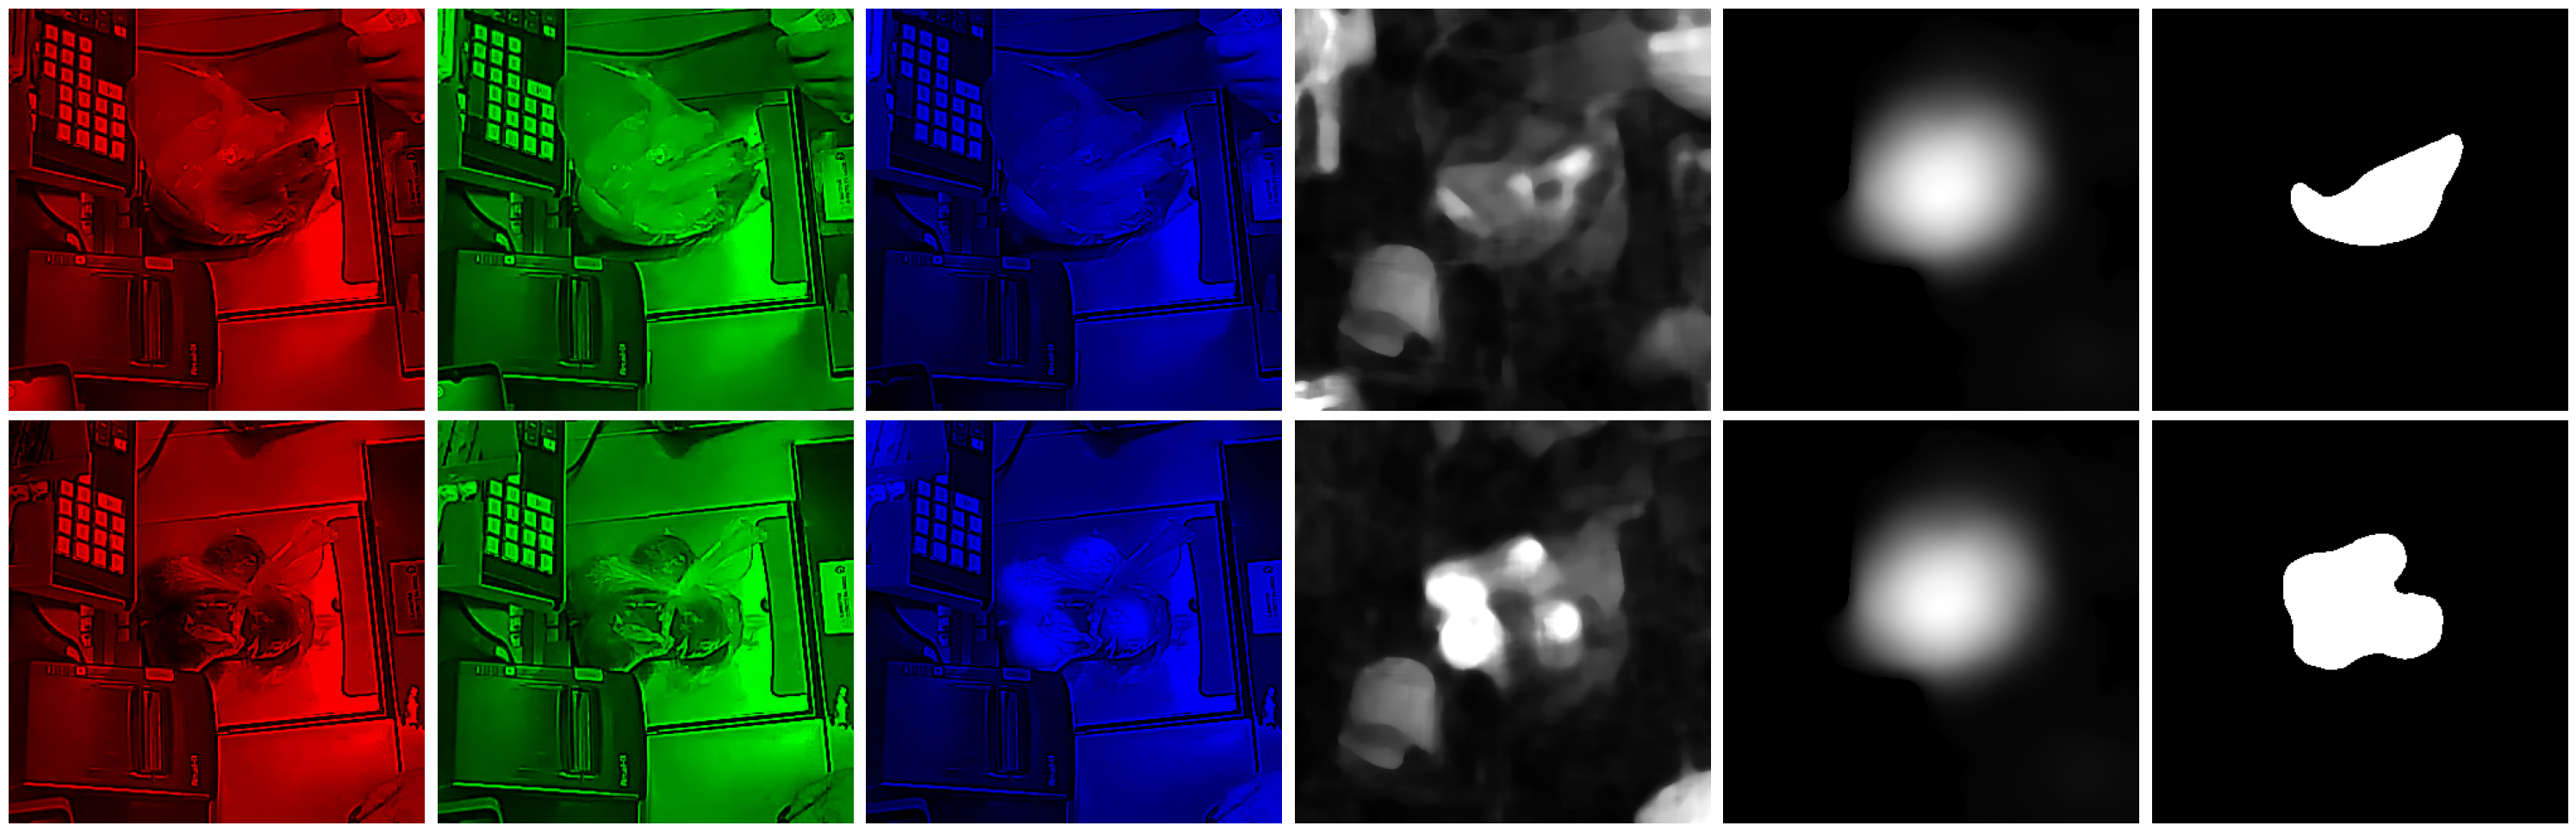

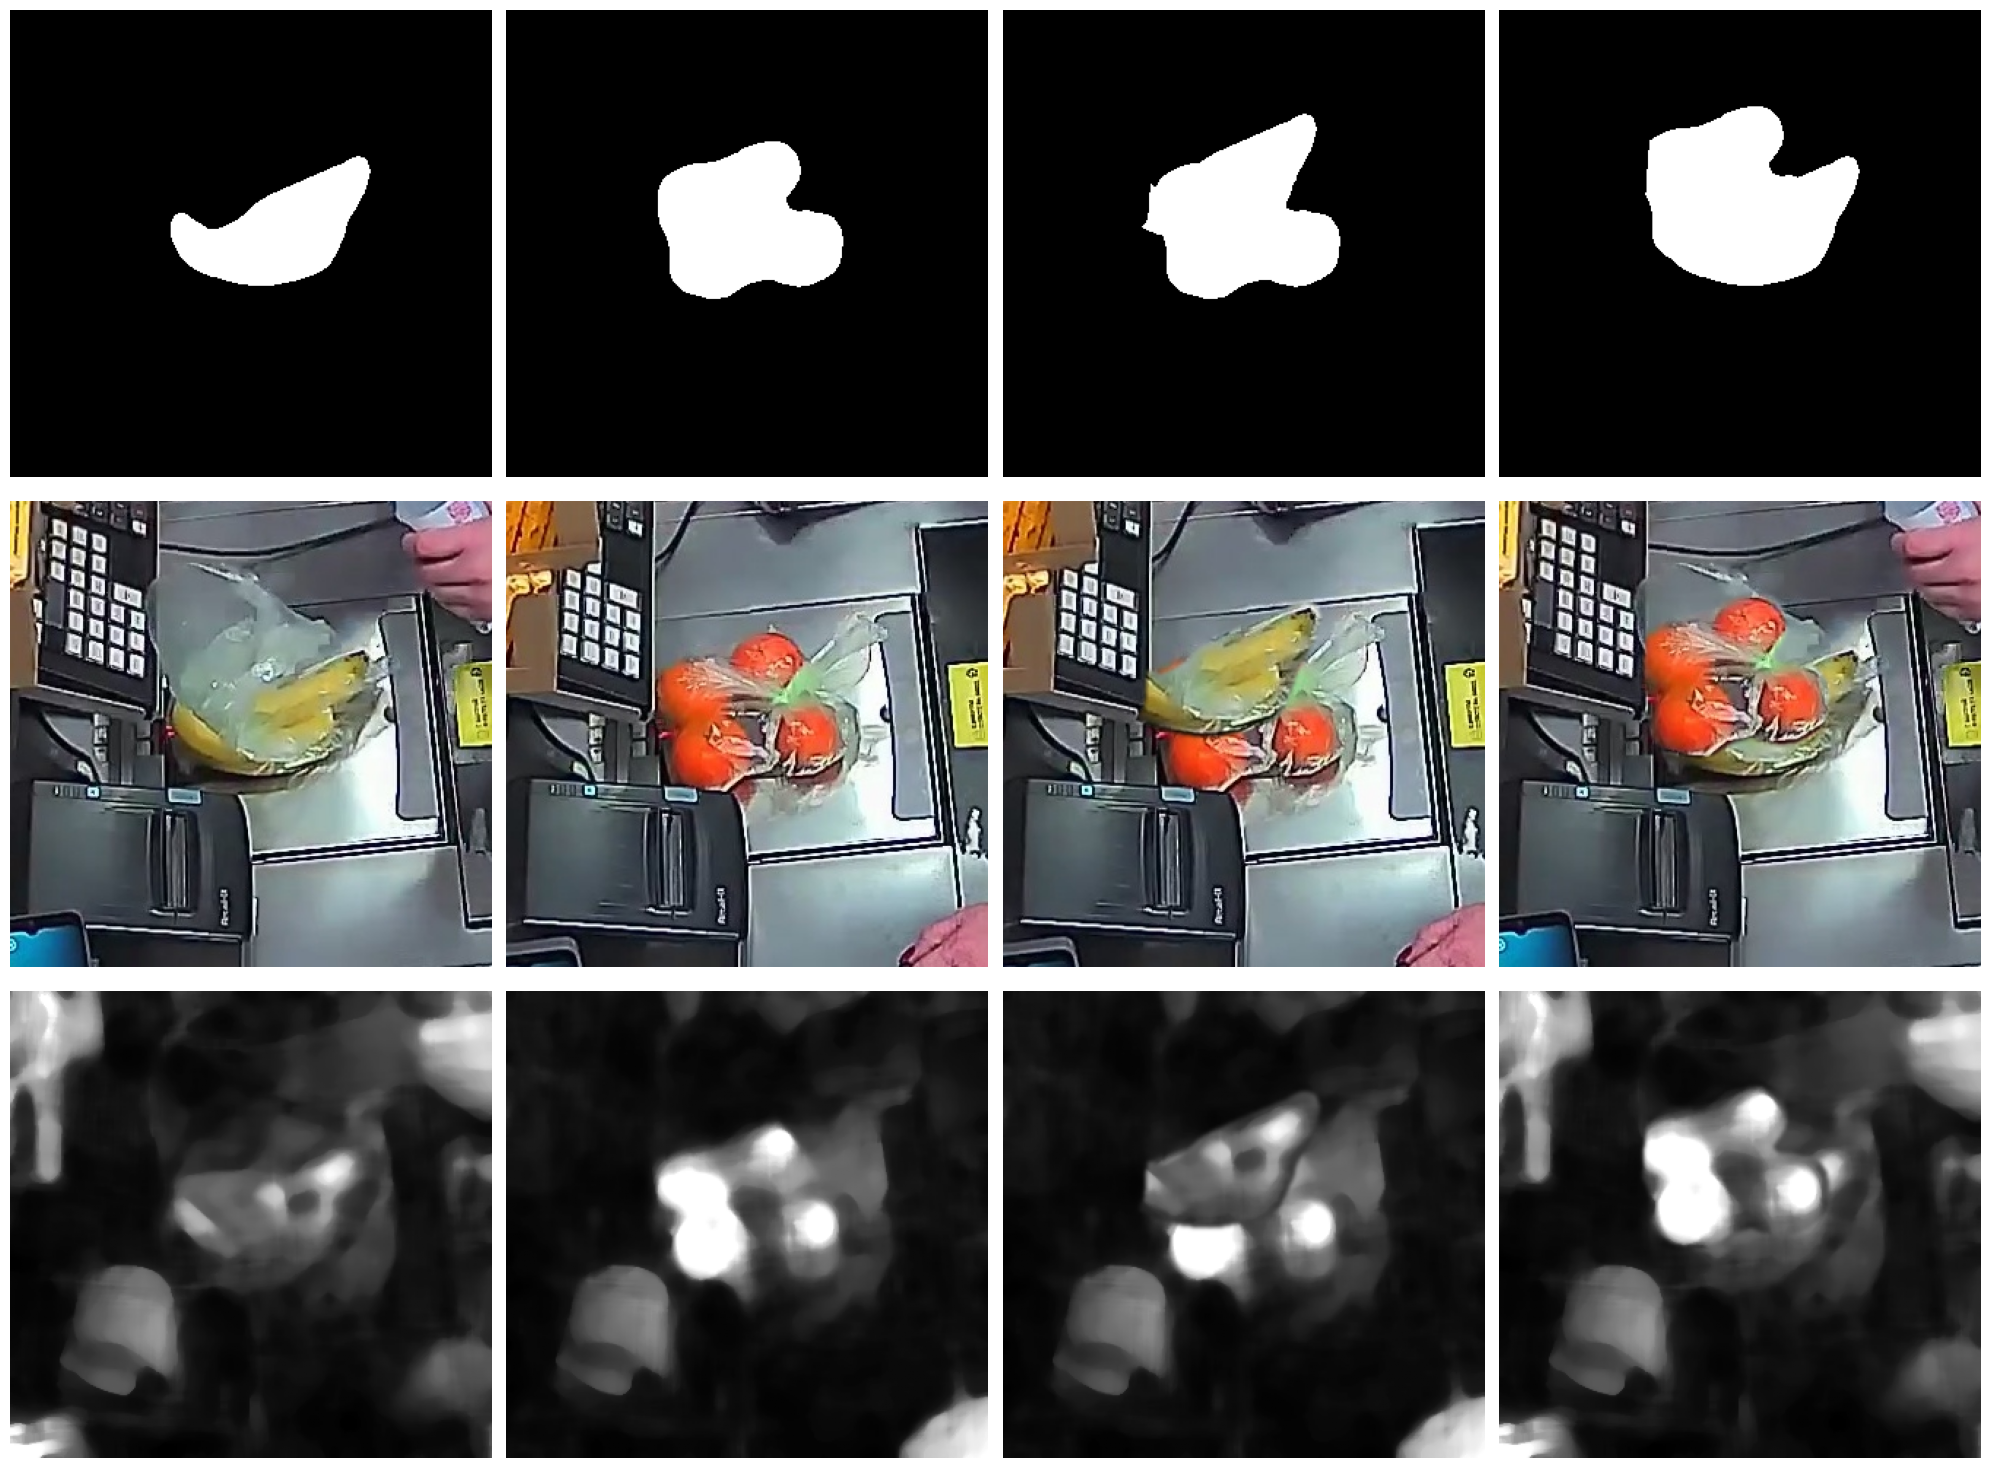

745589690ns, 10014846ns, 709082352ns
50.90%, 0.68%, 48.41%


In [ ]:
_start_time = time.time_ns()

loc = random.choice(tuple(LOCS.keys()))                         #
print(FN1 := random.choice(LOCS[loc]))                          #
print(FN2 := random.choice(LOCS[loc]))                          #
                                                                #  60.88%
CHW1, M1 = get_chw_tensor(FN1), maskload(FN1)                   #
CHW2, M2 = get_chw_tensor(FN2), maskload(FN2)                   #
                                                                #
imshow(*CHW1, M1, *CHW2, M2, grid=(2,6), cmap='rgb...rgb...',)  #

_dt1 = time.time_ns() - _start_time;_start_time = time.time_ns()

ACM21, M21 = aug(CHW1, M1, CHW2, M2)                           # 0.63%
ACM12, M12 = aug(CHW2, M2, CHW1, M1)                           #

_dt2 = time.time_ns() - _start_time;_start_time = time.time_ns()

rgbs = [x[:3].transpose(1, 2, 0) for x in (CHW1, CHW2, ACM12, ACM21)]  #
ds = [x[3] for x in (CHW1, CHW2, ACM12, ACM21)]                        # 38.49%
ms = [M1, M2, M12, M21]                                                #
imshow(*ms, *rgbs, *ds, grid=(3,4))                                    #

_dt3 = time.time_ns() - _start_time;print(f"{_dt1}ns, {_dt2}ns, {_dt3}ns")
_tt = _dt1 + _dt2 + _dt3;print(f"{_dt1/_tt*100:.2f}%, {_dt2/_tt*100:.2f}%, {_dt3/_tt*100:.2f}%")
# 1056647175ns, 10847729ns, 667985928ns
# 60.88%, 0.63%, 38.49%